<a href="https://colab.research.google.com/github/Le2se0hy/XAI_An/blob/main/SHAP_%EC%9D%B4%EB%AF%B8%EC%A7%80%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install osmnx geopandas openpyxl -q

컬럼 목록:
['year', 'Longitude', 'Latitude', 'YoungPop_Shapley_Value', 'Actual_price', 'Predicted_price', 'SHAP_Expected_Value', 'size', 'floor', 'unit', 'construction', 'parking per unit', 'max floor', 'heating', 'dist water', 'dist green', 'dist subway', 'dist office', 'highschool', 'bus stop', 'academy', 'population', 'median', 'young', 'sex ratio', 'density', 'spring', 'fall', 'winter', 'size_SHAP', 'floor_SHAP', 'unit_SHAP', 'construction_SHAP', 'parking per unit_SHAP', 'max floor_SHAP', 'heating_SHAP', 'dist water_SHAP', 'dist green_SHAP', 'dist subway_SHAP', 'dist office_SHAP', 'highschool_SHAP', 'bus stop_SHAP', 'academy_SHAP', 'population_SHAP', 'median_SHAP', 'young_SHAP', 'sex ratio_SHAP', 'density_SHAP', 'spring_SHAP', 'fall_SHAP', 'winter_SHAP']
전체 점 개수: 83433
서울 안쪽 점 개수: 83433


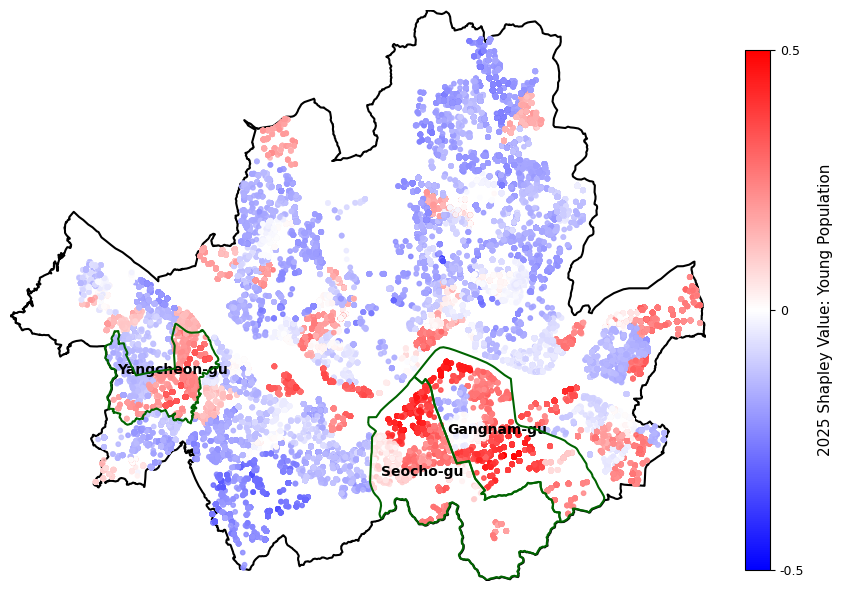

저장 완료: seoul_inside_geoshap_vertical_colorbar.jpg


In [8]:
# ============================================================
# 서울 윤곽선 안쪽 GeoSHAP 결과만 JPG로 저장
# + 오른쪽 세로 컬러바 포함
# + 색상범위 고정: -0.25 ~ 0.25
# + 컬러맵: blue - white - red
# ============================================================

import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# ============================================================
# 1. 엑셀 파일 불러오기
# ============================================================

file_path = "XGB_SHAP_2025.xlsx"   # 네 파일명으로 수정
# 그래프 출력 부분도 연도 필수 수
df = pd.read_excel(file_path)

print("컬럼 목록:")
print(df.columns.tolist())

# ============================================================
# 2. 컬럼명 설정 (네 파일에 맞게 수정)
# ============================================================

lon_col = "Longitude"
lat_col = "Latitude"
value_col = "YoungPop_Shapley_Value"   # <- 네 실제 GeoSHAP 값 컬럼명으로 수정

# ============================================================
# 3. 결측치 제거
# ============================================================

df = df.dropna(subset=[lon_col, lat_col, value_col])

# ============================================================
# 4. GeoDataFrame 변환
# ============================================================

gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
    crs="EPSG:4326"
)

# ============================================================
# 5. 서울 윤곽선 불러오기
# ============================================================

seoul = ox.geocode_to_gdf("Seoul, South Korea").to_crs(epsg=4326)

# ============================================================
# 5-1. 강조할 자치구(강남구, 서초구, 양천구) 윤곽선 불러오기
# ============================================================

target_districts = [
    "Yangcheon-gu, Seoul, South Korea",
    "Gangnam-gu, Seoul, South Korea",
    "Seocho-gu, Seoul, South Korea"
]

district_list = []
for district in target_districts:
    gdf_temp = ox.geocode_to_gdf(district).to_crs(epsg=4326)
    district_list.append(gdf_temp)

districts = pd.concat(district_list, ignore_index=True)
districts = gpd.GeoDataFrame(districts, crs="EPSG:4326")

# ============================================================
# 6. 서울 안쪽 점만 남기기
# ============================================================

gdf_inside = gpd.sjoin(
    gdf_points,
    seoul[["geometry"]],
    predicate="within",
    how="inner"
).drop(columns=["index_right"], errors="ignore")

print("전체 점 개수:", len(gdf_points))
print("서울 안쪽 점 개수:", len(gdf_inside))

# ============================================================
# 7. 컬러맵 / 색상범위 설정
# ============================================================

vmin = -0.5
vmax = 0.5

cmap = LinearSegmentedColormap.from_list(
    "blue_white_red",
    ["blue", "white", "red"]
)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# ============================================================
# 8. 지도 그리기
# ============================================================

fig, ax = plt.subplots(figsize=(10, 10))

# 서울 폴리곤
seoul.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=1.5
)

# 점 표시
gdf_inside.plot(
    ax=ax,
    column=value_col,
    cmap=cmap,
    norm=norm,
    markersize=10,
    alpha=0.85,
    legend=False
)

# 자치구 이름 표시
for idx, row in districts.iterrows():
    point = row.geometry.representative_point()
    name = row["display_name"].split(",")[0]   # 예: Gangnam-gu
    ax.text(
        point.x,
        point.y,
        name,
        fontsize=10,
        fontweight="bold",
        color="black",
        ha="center"
    )

# ------------------------------------------------------------
# 강남구, 서초구, 양천구 윤곽선만 강조
# ------------------------------------------------------------
districts.boundary.plot(
    ax=ax,
    edgecolor="darkgreen",   # 색 바꾸고 싶으면 "red", "blue", "black" 등 가능
    linewidth=1.5,
    zorder=5
)


# 서울 경계 기준으로 화면 자르기
minx, miny, maxx, maxy = seoul.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()


# ============================================================
# 9. 오른쪽 세로 컬러바 추가
# ============================================================

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# [left, bottom, width, height]
# 오른쪽에 세로 바 배치
fig.subplots_adjust(right=0.82)

cbar_ax = fig.add_axes([0.86, 0.22, 0.025, 0.52])

cbar = fig.colorbar(
    sm,
    cax=cbar_ax,
    orientation="vertical"
)

cbar.set_ticks([-0.5, 0, 0.5])
cbar.set_ticklabels(["-0.5", "0", "0.5"])

cbar.set_label(
    "2025 Shapley Value: Young Population", # 원하는 결과마다 연도 바꾸기
    fontsize=11,
    labelpad=10
)

cbar.ax.tick_params(labelsize=9)

# ============================================================
# 10. 저장
# ============================================================

output_path = "seoul_inside_geoshap_vertical_colorbar.jpg"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("저장 완료:", output_path)